🎯 Starting Agile Sprint 1: Exploratory Data Analysis
✅ Data loaded successfully! Shape: (7043, 20)
📊 Dataset Info: 7043 rows, 20 columns

🔍 BASIC DATASET INFORMATION:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   object 
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies 

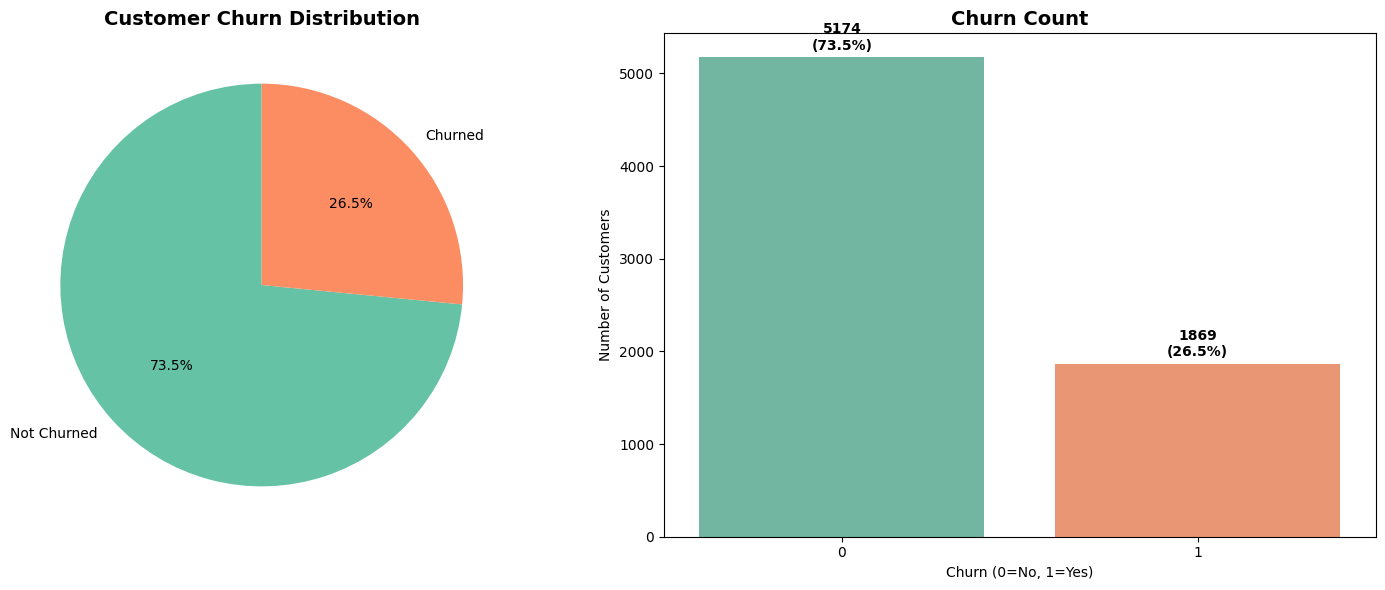


📊 VISUALIZATION 2: Numerical Features by Churn


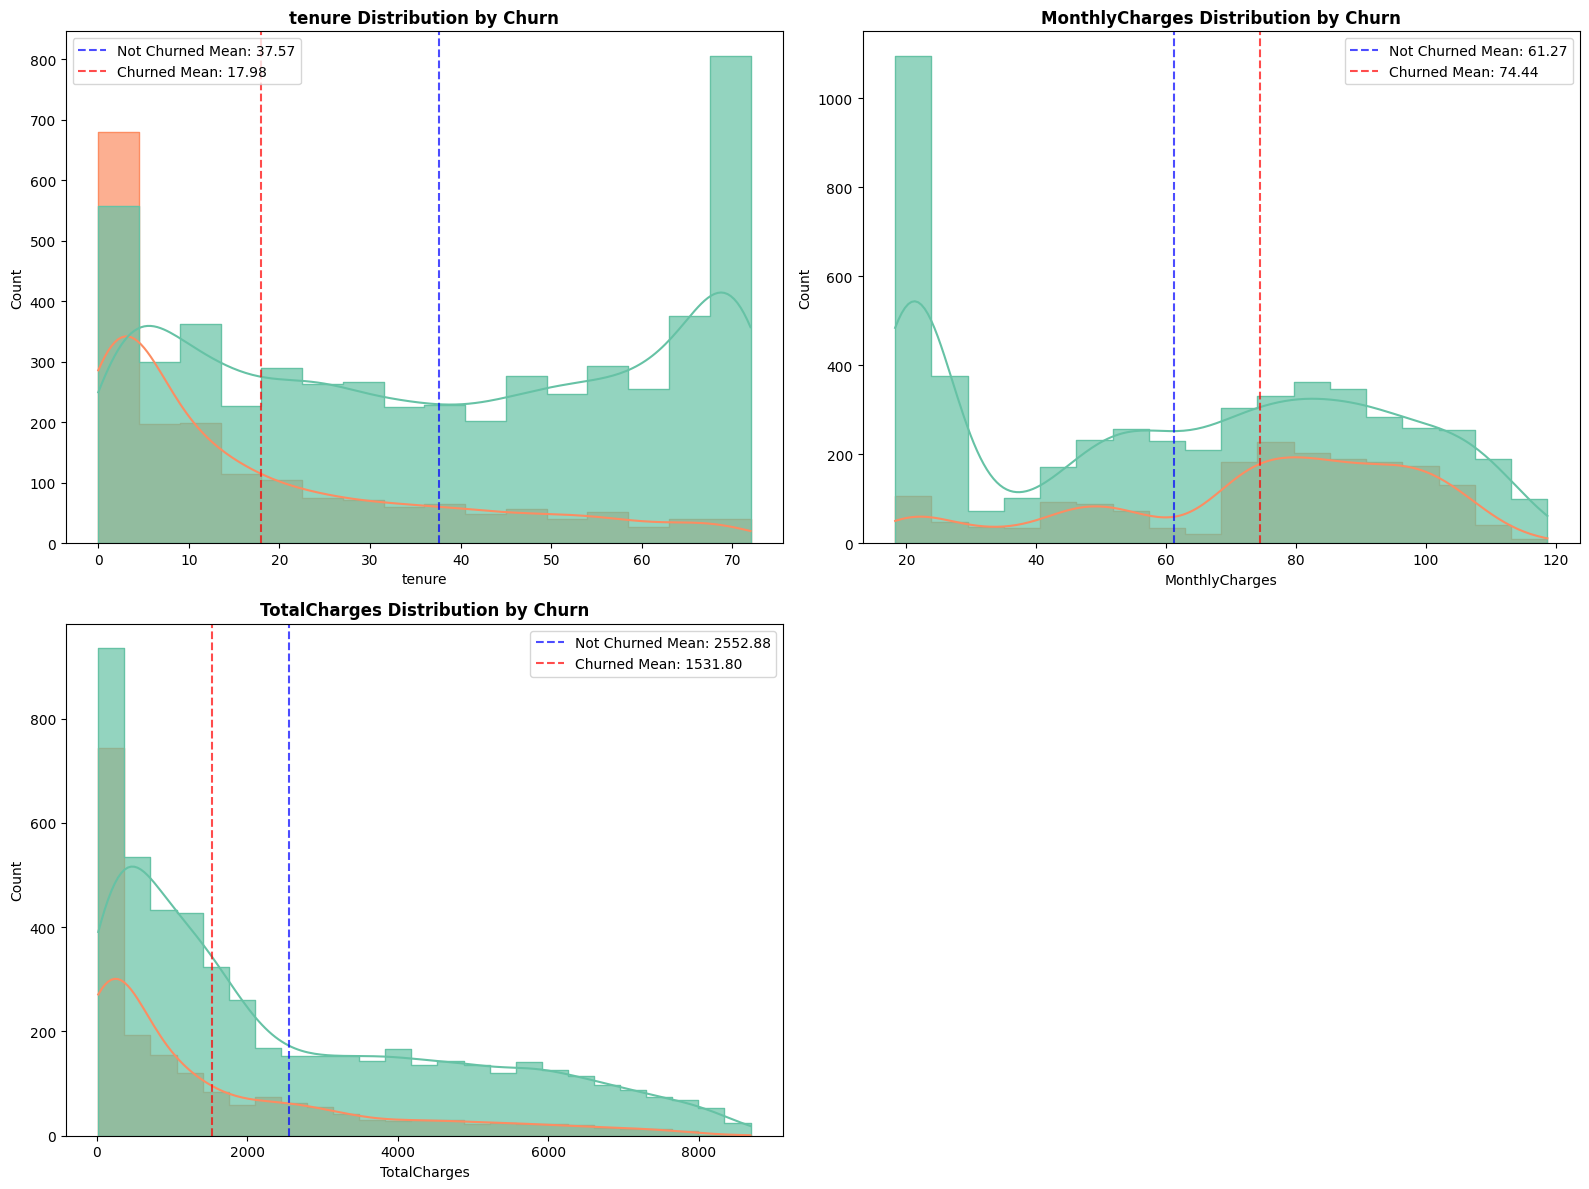


📊 VISUALIZATION 3: Categorical Features Analysis


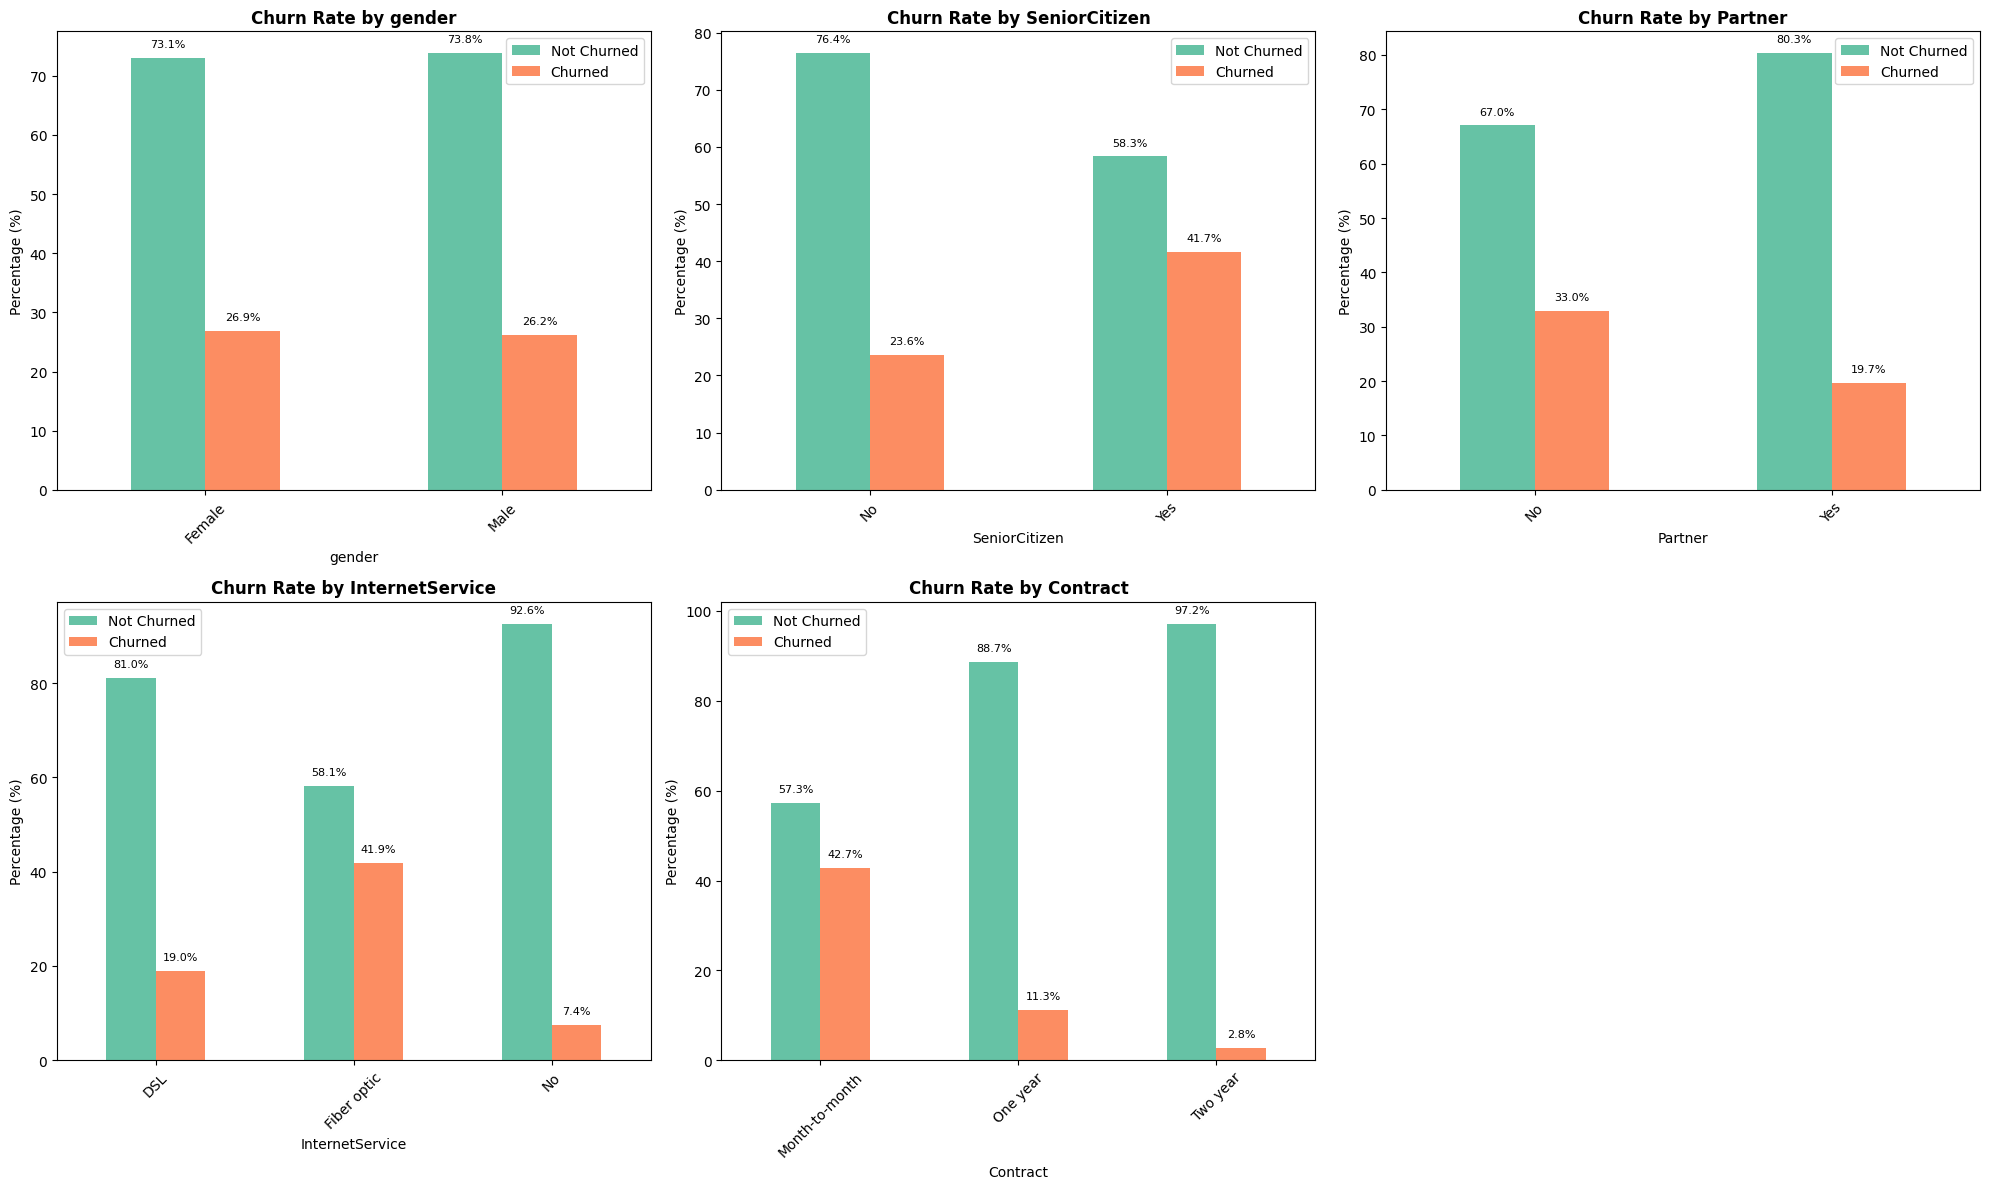


📊 VISUALIZATION 4: Correlation Matrix


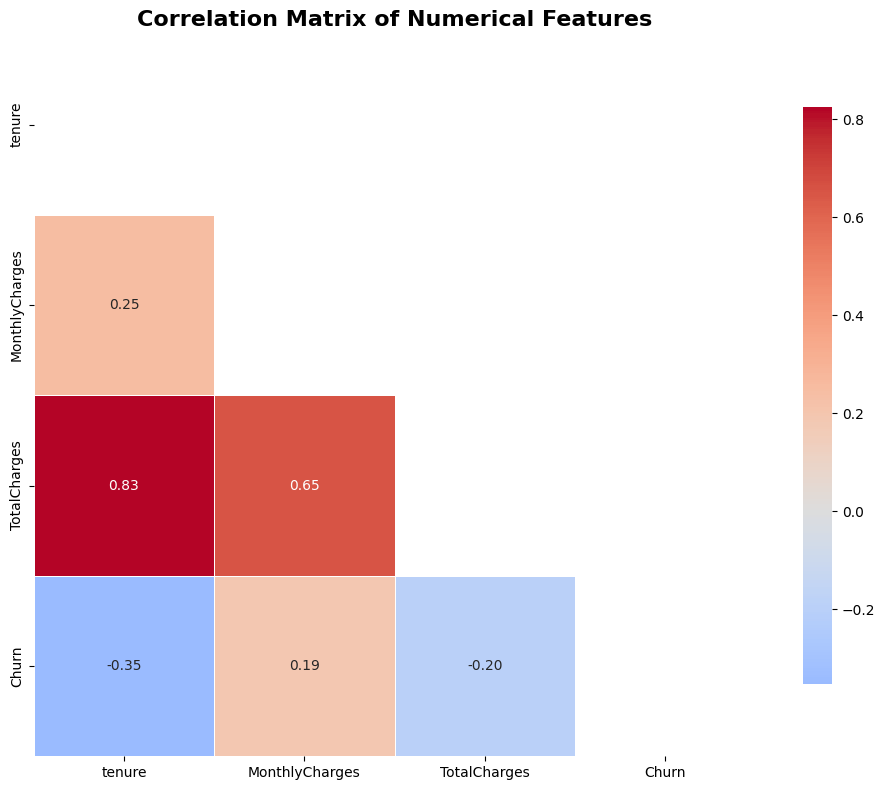


💡 KEY INSIGHTS FROM EDA:
1. Average Tenure:
   - Churned Customers: 18.0 months
   - Not Churned Customers: 37.6 months
2. Average Monthly Charges:
   - Churned Customers: $74.44
   - Not Churned Customers: $61.27
3. Churn Rate by Contract Type:
   - Month-to-month: 42.7%
   - One year: 11.3%
   - Two year: 2.8%

🎉 EDA Completed Successfully!
📁 Visualizations saved in: models/model_performance/
🚀 Next: Feature Engineering and Model Training


In [3]:
# notebooks/01_eda.ipynb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('default')
sns.set_palette("Set2")
%matplotlib inline

print("🎯 Starting Agile Sprint 1: Exploratory Data Analysis")
print("=" * 60)

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_churn_data.csv')
print(f"✅ Data loaded successfully! Shape: {df.shape}")
print(f"📊 Dataset Info: {df.shape[0]} rows, {df.shape[1]} columns")

# Basic Information
print("\n🔍 BASIC DATASET INFORMATION:")
print("=" * 40)
print(df.info())
print(f"\n📈 Statistical Summary:")
print(df.describe())

# Target Variable Analysis
print("\n🎯 TARGET VARIABLE ANALYSIS (CHURN):")
print("=" * 40)
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

print(f"Churn Distribution:")
print(f"0 (Not Churned): {churn_counts[0]} customers ({churn_percentage[0]:.2f}%)")
print(f"1 (Churned): {churn_counts[1]} customers ({churn_percentage[1]:.2f}%)")

# 1. Target Variable Visualization
print("\n📊 VISUALIZATION 1: Churn Distribution")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart
axes[0].pie(churn_counts.values, labels=['Not Churned', 'Churned'], 
            autopct='%1.1f%%', startangle=90, colors=['#66c2a5', '#fc8d62'])
axes[0].set_title('Customer Churn Distribution', fontsize=14, fontweight='bold')

# Bar plot
sns.countplot(data=df, x='Churn', ax=axes[1], palette=['#66c2a5', '#fc8d62'])
axes[1].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Churn (0=No, 1=Yes)')
axes[1].set_ylabel('Number of Customers')

# Add percentage labels on bars
for i, count in enumerate(churn_counts.values):
    axes[1].text(i, count + 50, f'{count}\n({churn_percentage[i]:.1f}%)', 
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('../models/model_performance/churn_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# 2. Numerical Features Analysis
print("\n📊 VISUALIZATION 2: Numerical Features by Churn")
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for i, col in enumerate(numerical_cols):
    row, col_idx = i // 2, i % 2
    # Distribution plot
    sns.histplot(data=df, x=col, hue='Churn', ax=axes[row, col_idx], 
                 kde=True, alpha=0.7, element='step')
    axes[row, col_idx].set_title(f'{col} Distribution by Churn', fontweight='bold')
    axes[row, col_idx].set_xlabel(col)
    
    # Add mean lines
    mean_churn_0 = df[df['Churn'] == 0][col].mean()
    mean_churn_1 = df[df['Churn'] == 1][col].mean()
    axes[row, col_idx].axvline(mean_churn_0, color='blue', linestyle='--', alpha=0.7, label=f'Not Churned Mean: {mean_churn_0:.2f}')
    axes[row, col_idx].axvline(mean_churn_1, color='red', linestyle='--', alpha=0.7, label=f'Churned Mean: {mean_churn_1:.2f}')
    axes[row, col_idx].legend()

# Remove empty subplot
axes[1, 1].remove()
plt.tight_layout()
plt.savefig('../models/model_performance/numerical_features.png', dpi=300, bbox_inches='tight')
plt.show()

# 3. Categorical Features Analysis
print("\n📊 VISUALIZATION 3: Categorical Features Analysis")
categorical_cols = ['gender', 'SeniorCitizen', 'Partner', 'InternetService', 'Contract']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.ravel()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        # Create cross tabulation
        cross_tab = pd.crosstab(df[col], df['Churn'], normalize='index') * 100
        
        # Plot
        cross_tab.plot(kind='bar', ax=axes[i], color=['#66c2a5', '#fc8d62'])
        axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Percentage (%)')
        axes[i].legend(['Not Churned', 'Churned'])
        axes[i].tick_params(axis='x', rotation=45)
        
        # Add percentage labels
        for p in axes[i].patches:
            axes[i].annotate(f'{p.get_height():.1f}%', 
                           (p.get_x() + p.get_width() / 2., p.get_height()), 
                           ha='center', va='center', 
                           xytext=(0, 10), 
                           textcoords='offset points',
                           fontsize=8)

# Remove empty subplots
for i in range(len(categorical_cols), len(axes)):
    axes[i].remove()

plt.tight_layout()
plt.savefig('../models/model_performance/categorical_features.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. Correlation Analysis
print("\n📊 VISUALIZATION 4: Correlation Matrix")
# Select only numerical columns for correlation
numerical_df = df[numerical_cols + ['Churn']]

plt.figure(figsize=(10, 8))
correlation_matrix = numerical_df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5, fmt='.2f', mask=mask,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Matrix of Numerical Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('../models/model_performance/correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# 5. Key Insights Summary
print("\n💡 KEY INSIGHTS FROM EDA:")
print("=" * 40)

# Insight 1: Tenure vs Churn
avg_tenure_churn = df.groupby('Churn')['tenure'].mean()
print(f"1. Average Tenure:")
print(f"   - Churned Customers: {avg_tenure_churn[1]:.1f} months")
print(f"   - Not Churned Customers: {avg_tenure_churn[0]:.1f} months")

# Insight 2: Monthly Charges
avg_charges_churn = df.groupby('Churn')['MonthlyCharges'].mean()
print(f"2. Average Monthly Charges:")
print(f"   - Churned Customers: ${avg_charges_churn[1]:.2f}")
print(f"   - Not Churned Customers: ${avg_charges_churn[0]:.2f}")

# Insight 3: Contract Type
contract_churn = df.groupby('Contract')['Churn'].mean() * 100
print(f"3. Churn Rate by Contract Type:")
for contract, rate in contract_churn.items():
    print(f"   - {contract}: {rate:.1f}%")

print("\n🎉 EDA Completed Successfully!")
print("📁 Visualizations saved in: models/model_performance/")
print("🚀 Next: Feature Engineering and Model Training")